# Análisis de Sentimiento

## 1. Librerías y configuraciones

In [2]:
import os
from pathlib import Path
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
OUTPUT_DIR = Path("2_Modelos/sentiment")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_CSV = "1_Data/processed/sentiment_data.csv"  

# Device (MPS aware)
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)

DEVICE: mps


## 2. Hiperparámetros

In [4]:
# Definir 3 modelos a comparar
MODELS_TO_COMPARE = {
    "distilbert": "distilbert-base-uncased",
    #"roberta": "roberta-base", -> no corre
    #"mdeberta": "microsoft/mdeberta-v3-base", -> no corre
    #"bert": "bert-base-uncased" -> no corre
    "minilm":"sentence-transformers/all-MiniLM-L6-v2",
    #"tinybert":"prajjwal1/bert-tiny", 
    #"funnel_small": "funnel-transformer/small"
}

# Definir 3 configuraciones diferentes para cada modelo
CONFIGS = {
    "config_1": {
        "MAX_LENGTH": 128,
        "BATCH_SIZE": 8,
        "NUM_EPOCHS": 3,
        "LEARNING_RATE": 5e-5,
        "WARMUP_RATIO": 0.1,
        "WEIGHT_DECAY": 0.01,
    },
    "config_2": {
        "MAX_LENGTH": 256,
        "BATCH_SIZE": 4,
        "NUM_EPOCHS": 5,
        "LEARNING_RATE": 3e-5,
        "WARMUP_RATIO": 0.15,
        "WEIGHT_DECAY": 0.02,
    },
    "config_3": {
        "MAX_LENGTH": 256,
        "BATCH_SIZE": 8,
        "NUM_EPOCHS": 5,
        "LEARNING_RATE": 2e-5,
        "WARMUP_RATIO": 0.2,
        "WEIGHT_DECAY": 0.01,
    }
}

# Parámetros comunes
GRAD_CLIP = 1.0
EARLY_STOPPING_PATIENCE = 3
EVAL_STEPS = 200
SAVE_STEPS = 200
LOGGING_STEPS = 50

LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}


## 3. Carga y preparación de datos

In [5]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
import re

stop_words = set(stopwords.words("english"))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # solo letras y espacios
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arielamishaancohen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
df = pd.read_csv(DATA_CSV)
df = df.rename(columns={"full_content": "text"})
df.head()


,title,description,content,text,source,author,publishedAt,url,sentiment
0,Brockton mayoral race heats up as Derenoncourt...,Did a finalist to be Brockton's next mayor duc...,BROCKTON Did a finalist to be Brockton's next ...,BROCKTON — Did a finalist to be Brockton's nex...,Enterprise News,"Chris Helms, The Enterprise",2025-10-23T18:06:11Z,https://www.enterprisenews.com/story/news/poli...,neutral
1,Bruce Springsteen lent helping hand to directo...,"Bruce Springsteen, the legendary musician, dem...",<ul><li>News</li>\r\n<li>Bruce Springsteen len...,"Bruce Springsteen, the legendary musician, dem...",The Times of India,IANS,2025-10-23T18:05:51Z,https://timesofindia.indiatimes.com/entertainm...,neutral
2,Binance Founder Changpeng Zhao Receives Pardon...,U.S. President Donald Trump has granted Binanc...,U.S. President Donald Trump has granted Binanc...,Advertisement\n\nU.S. President Donald Trump h...,ZyCrypto,Brenda Ngari,2025-10-23T18:03:17Z,https://zycrypto.com/binance-founder-changpeng...,neutral
3,A Mandatory Paper Bag Fee May Be Coming to Phi...,Check phillymag.com each morning Monday throug...,"NewsPlus, Philly mob documentary makes a big s...",A Mandatory Paper Bag Fee May Be Coming to Phi...,phillymag.com,Victor Fiorillo,2025-10-23T18:03:12Z,https://www.phillymag.com/news/2025/10/23/plas...,neutral
4,Wilco and Billy Bragg to Perform Mermaid Avenu...,"""Mermaid Avenue Live"" is set to take place at ...",Wilco and Billy Bragg have announced they will...,Wilco and Billy Bragg have announced they will...,Consequence.net,Eddie Fu,2025-10-23T18:02:51Z,https://consequence.net/2025/10/wilco-billy-br...,neutral


In [7]:
df['text'] = df['text'].apply(clean_text)


### Mapear labels

In [8]:
if "sentiment" in df.columns:
    df["label"] = df["sentiment"].map(LABEL2ID)
else:
    df["label"] = df["label"].astype(int)

df.head()


,title,description,content,text,source,author,publishedAt,url,sentiment,label
0,Brockton mayoral race heats up as Derenoncourt...,Did a finalist to be Brockton's next mayor duc...,BROCKTON Did a finalist to be Brockton's next ...,brockton finalist brockton next mayor duck deb...,Enterprise News,"Chris Helms, The Enterprise",2025-10-23T18:06:11Z,https://www.enterprisenews.com/story/news/poli...,neutral,1
1,Bruce Springsteen lent helping hand to directo...,"Bruce Springsteen, the legendary musician, dem...",<ul><li>News</li>\r\n<li>Bruce Springsteen len...,bruce springsteen legendary musician demonstra...,The Times of India,IANS,2025-10-23T18:05:51Z,https://timesofindia.indiatimes.com/entertainm...,neutral,1
2,Binance Founder Changpeng Zhao Receives Pardon...,U.S. President Donald Trump has granted Binanc...,U.S. President Donald Trump has granted Binanc...,advertisement u president donald trump granted...,ZyCrypto,Brenda Ngari,2025-10-23T18:03:17Z,https://zycrypto.com/binance-founder-changpeng...,neutral,1
3,A Mandatory Paper Bag Fee May Be Coming to Phi...,Check phillymag.com each morning Monday throug...,"NewsPlus, Philly mob documentary makes a big s...",mandatory paper bag fee may coming philly stor...,phillymag.com,Victor Fiorillo,2025-10-23T18:03:12Z,https://www.phillymag.com/news/2025/10/23/plas...,neutral,1
4,Wilco and Billy Bragg to Perform Mermaid Avenu...,"""Mermaid Avenue Live"" is set to take place at ...",Wilco and Billy Bragg have announced they will...,wilco billy bragg announced perform collaborat...,Consequence.net,Eddie Fu,2025-10-23T18:02:51Z,https://consequence.net/2025/10/wilco-billy-br...,neutral,1


In [9]:
print("Distribución:")
print(df["sentiment"].value_counts())
print(df["sentiment"].value_counts(normalize=True))


Distribución:
sentiment
neutral     504
positive    108
negative     71
Name: count, dtype: int64
sentiment
neutral     0.737921
positive    0.158126
negative    0.103953
Name: proportion, dtype: float64


### Split train, val y test

In [10]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"])

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


Train: 546, Val: 68, Test: 69


## 4. Pesos de clase

In [11]:
labels = train_df["label"].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)


Class weights: tensor([3.1930, 0.4516, 2.1163])


## 5. Trainer personalizado (weighted loss)

In [12]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights_tensor, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights_tensor

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        device = model.device
        inputs = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in inputs.items()}
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        class_weights = self._class_weights.to(device)
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


## 6. Métricas y evaluación

In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weight = f1_score(labels, preds, average='weighted')

    metrics = {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weight,
    }

    # Añadir f1 por clase
    f1s = f1_score(labels, preds, average=None)
    for i, val in enumerate(f1s):
        metrics[f"f1_{ID2LABEL[i]}"] = float(val)

    return metrics


In [14]:
# Chunk 1: Función para el Experimento Baseline (Colocar después de compute_metrics)
from transformers import Trainer # Asegurarse de que Trainer esté importado

def run_baseline_experiment_sentiment(model_key, model_name, test_ds, output_dir, device):
    """
    Evalúa el modelo pre-entrenado (baseline) directamente en el conjunto de prueba
    sin realizar fine-tuning, y devuelve los resultados en el formato final.
    """
    print(f"\n{'='*80}\n▶️ Ejecutando Experimento BASELINE: {model_key}\n{'='*80}")
    
    experiment_key = f"{model_key}_BASE"
    
    # 1. Cargar el modelo base
    num_labels = len(LABEL2ID) # Usa la variable global
    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_labels,
            id2label=ID2LABEL, # Usa la variable global
            label2id=LABEL2ID, # Usa la variable global
            ignore_mismatched_sizes=True 
        ).to(device)
    except Exception as e:
        print(f"❌ Error al cargar el modelo {model_name}: {e}. Omitiendo Baseline.")
        return None, None, None # Devuelve None si falla

    # 2. Configurar el Trainer solo para predicción/evaluación
    training_args = TrainingArguments(
        output_dir=output_dir / "baseline" / model_key,
        per_device_eval_batch_size=16,
        do_train=False,
        do_eval=False,
        do_predict=True,
        report_to="none",
        log_level="error",
        metric_for_best_model="f1_macro", 
    )
    
    # Usamos Trainer estándar, ya que no estamos calculando la pérdida ponderada del entrenamiento
    trainer = Trainer(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics # Usa la función global
    )
    
    # 3. Predecir y obtener métricas
    predictions = trainer.predict(test_ds)
    preds = np.argmax(predictions.predictions, axis=1)
    
    # 4. Formatear resultados para all_results (para el final_summary)
    all_results_data = {
        "model_key": model_key,
        "model_name": model_name,
        "config_name": 'BASE',
        "config": {k: 'N/A' for k in CONFIGS['config_1'].keys()},
        "val_metrics": {'eval_loss': predictions.metrics.get('test_loss', np.nan)}, 
        "model_path": 'BASELINE_PRETRAINED',
        "tokenizer": None, 
        "test_ds": test_ds,
    }
    
    # 5. Formatear resultados para test_results (para el comparison_df)
    test_results_data = {
        "metrics": predictions.metrics,
        "predictions": preds,
        "labels": predictions.label_ids,
        "probabilities": torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy(),
        "model_key": model_key,
        "config_name": 'BASE',
    }
    
    print(f"✅ {experiment_key} completado")
    print(f"Test F1 Macro: {predictions.metrics.get('test_f1_macro', np.nan):.4f}")
    
    del model
    torch.cuda.empty_cache()

    return experiment_key, all_results_data, test_results_data

## 7. Función de preparación de datasets

In [15]:
def prepare_datasets(tokenizer, max_length, train_df, val_df, test_df):
    """Prepara datasets tokenizados para un modelo específico"""
    
    def preprocess_texts(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding='max_length',
            max_length=max_length,
        )
    
    train_ds = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True))
    val_ds = Dataset.from_pandas(val_df[["text", "label"]].reset_index(drop=True))
    test_ds = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True))

    train_ds = train_ds.map(preprocess_texts, batched=True, remove_columns=["text"])
    val_ds = val_ds.map(preprocess_texts, batched=True, remove_columns=["text"])
    test_ds = test_ds.map(preprocess_texts, batched=True, remove_columns=["text"])

    train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    
    return train_ds, val_ds, test_ds


## 8. Función de entrenamiento de modelo

In [16]:
def train_model(model_name, model_key, config_name, config, train_ds, val_ds):
    """
    Entrena un modelo con una configuración específica
    
    Args:
        model_name: Nombre del modelo (ej: "distilbert-base-uncased")
        model_key: Clave del modelo (ej: "distilbert")
        config_name: Nombre de la configuración (ej: "config_1")
        config: Dict con hiperparámetros
        train_ds, val_ds: Datasets de entrenamiento y validación
    
    Returns:
        model, trainer, metrics
    """
    print(f"\n{'='*80}")
    print(f"Entrenando: {model_key} - {config_name}")
    print(f"{'='*80}\n")
    
    # Crear directorio específico para este experimento
    exp_dir = OUTPUT_DIR / f"{model_key}_{config_name}"
    exp_dir.mkdir(parents=True, exist_ok=True)
    
    # Cargar modelo
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(LABEL2ID),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )
    model.to(DEVICE)
    
    # Training arguments
    training_args = TrainingArguments(
        output_dir=str(exp_dir),
        #disable_tqdm = True, 
        #report_to = "none",
        eval_strategy="steps",
        eval_steps=EVAL_STEPS,
        save_strategy="steps",
        save_steps=SAVE_STEPS,
        learning_rate=config["LEARNING_RATE"],
        per_device_train_batch_size=config["BATCH_SIZE"],
        per_device_eval_batch_size=config["BATCH_SIZE"],
        num_train_epochs=config["NUM_EPOCHS"],
        warmup_ratio=config["WARMUP_RATIO"],
        weight_decay=config["WEIGHT_DECAY"],
        logging_steps=LOGGING_STEPS,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        max_grad_norm=GRAD_CLIP,
        lr_scheduler_type="cosine",
    )
    
    # Trainer
    trainer = WeightedTrainer(
        class_weights_tensor=class_weights,
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )
    
    # Entrenar
    train_result = trainer.train()
    
    # Guardar modelo y métricas
    trainer.save_model(str(exp_dir / "final_model"))
    with open(exp_dir / "training_metrics.json", "w") as f:
        json.dump(train_result.metrics, f, indent=2)
    
    # Evaluar en validación
    val_metrics = trainer.evaluate()
    
    return model, trainer, val_metrics


## 9. Entranemiento de los modelos

In [17]:
# Diccionario para almacenar resultados
all_results = {}

In [18]:
# Chunk 2: Bucle Principal Unificado (REEMPLAZA TODA LA SECCIÓN DE EJECUCIÓN DE MODELOS)

all_results = {}
test_results = {} # Inicializamos test_results aquí para incluir el baseline

# Usaremos la configuración MAX_LENGTH de la config_1 como referencia para el tokenizador
# inicial del Baseline (la elección de la config_1 es arbitraria, solo para tokenizar una vez).
REFERENCE_MAX_LENGTH = CONFIGS["config_1"]["MAX_LENGTH"]

# Bucle principal de experimentos: Itera sobre todos los modelos
for model_key, model_name in MODELS_TO_COMPARE.items():
    print(f"\n{'#'*80}\n# Iniciando experimentos para el modelo: {model_key.upper()} ({model_name})\n{'#'*80}")
    
    # 1. Inicializar tokenizador para el modelo actual
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Crear datasets tokenizados de REFERENCIA (usando el MAX_LENGTH de config_1)
    # Esto lo necesita el Baseline.
    train_ds_base, val_ds_base, test_ds_base = prepare_datasets(
        tokenizer, 
        REFERENCE_MAX_LENGTH, 
        train_df, 
        val_df, 
        test_df
    )
    
    # 2. 🚀 Ejecutar Experimento BASELINE (Modelo sin Fine-Tuning)
    exp_key_base, all_res_base, test_res_base = run_baseline_experiment_sentiment(
        model_key, 
        model_name, 
        test_ds_base, 
        OUTPUT_DIR, 
        DEVICE
    )
    
    if exp_key_base:
        all_results[exp_key_base] = all_res_base
        test_results[exp_key_base] = test_res_base

    # 3. 🧠 Ejecutar Experimentos de Fine-Tuning (Itera sobre todas las configuraciones)
    for config_name, config in CONFIGS.items():
        experiment_key = f"{model_key}_{config_name}"
        
        # Preparar datasets con el max_length de ESTA configuración
        train_ds, val_ds, test_ds_prepared = prepare_datasets(
            tokenizer, 
            config["MAX_LENGTH"], 
            train_df, 
            val_df, 
            test_df
        )
        
        # Entrenar modelo
        try:
            model, trainer, val_metrics = train_model(
                model_name, 
                model_key, 
                config_name, 
                config,
                train_ds, 
                val_ds
            )
            
            # Guardar resultados de Fine-Tuning en all_results
            all_results[experiment_key] = {
                "model_key": model_key,
                "model_name": model_name,
                "config_name": config_name,
                "config": config,
                "val_metrics": val_metrics,
                "model_path": str(OUTPUT_DIR / f"{model_key}_{config_name}" / "final_model"),
                "tokenizer": tokenizer,
                "test_ds": test_ds_prepared,
            }
            
            print(f"\n✅ {experiment_key} completado (Fine-Tuning)")
            
            # 4. 📝 Evaluar el modelo FINE-TUNED en el Test Set y guardar directamente en test_results
            print(f"Evaluando {experiment_key} en Test Set...")
            
            # Recreamos un Trainer para la evaluación
            training_args_eval = TrainingArguments(
                output_dir=str(OUTPUT_DIR / "temp" / experiment_key),
                per_device_eval_batch_size=16,
                do_train=False, do_eval=False, do_predict=True, report_to="none",
                log_level="error",
            )
            
            # Usamos WeightedTrainer para la evaluación (aunque la pérdida ponderada no aplica aquí)
            trainer_eval = WeightedTrainer(
                class_weights_tensor=class_weights, # Usa la variable global
                model=model,
                args=training_args_eval,
                compute_metrics=compute_metrics,
            )
            
            # Predecir en test
            predictions = trainer_eval.predict(test_ds_prepared)
            preds = np.argmax(predictions.predictions, axis=1)
            
            # Guardar resultados de Test
            test_results[experiment_key] = {
                "metrics": predictions.metrics,
                "predictions": preds,
                "labels": predictions.label_ids,
                "probabilities": torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy(),
                "model_key": model_key,
                "config_name": config_name,
            }
            
            print(f"Test F1 Macro: {predictions.metrics['test_f1_macro']:.4f}")
            
            # Limpieza de memoria
            del model
            torch.cuda.empty_cache()

        except Exception as e:
            print(f"\n❌ Error en {experiment_key}: {str(e)}")
            if 'model' in locals():
                del model
            torch.cuda.empty_cache()
            continue

print("\n" + "="*80)
print("TODOS LOS EXPERIMENTOS COMPLETADOS (Baseline y Fine-Tuning)")
print("="*80)


################################################################################
# Iniciando experimentos para el modelo: DISTILBERT (distilbert-base-uncased)
################################################################################


Map:   0%|          | 0/546 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

Map:   0%|          | 0/69 [00:00<?, ? examples/s]


▶️ Ejecutando Experimento BASELINE: distilbert


...

{'loss': 0.9911, 'grad_norm': 3.6616055965423584, 'learning_rate': 5.399349622688479e-06, 'epoch': 3.6231884057971016}
{'loss': 0.9795, 'grad_norm': 2.7921009063720703, 'learning_rate': 1.339745962155613e-06, 'epoch': 4.3478260869565215}
{'train_runtime': 55.9866, 'train_samples_per_second': 48.762, 'train_steps_per_second': 6.162, 'train_loss': 1.0353995502858921, 'epoch': 5.0}


/Users/arielamishaancohen/Library/Python/3.10/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 1.0624339580535889, 'eval_accuracy': 0.7352941176470589, 'eval_f1_macro': 0.4165191740412979, 'eval_f1_weighted': 0.6658511192087454, 'eval_f1_negative': 0.4, 'eval_f1_neutral': 0.8495575221238938, 'eval_f1_positive': 0.0, 'eval_runtime': 0.3126, 'eval_samples_per_second': 217.519, 'eval_steps_per_second': 28.789, 'epoch': 5.0}

✅ minilm_config_3 completado (Fine-Tuning)
Evaluando minilm_config_3 en Test Set...


/Users/arielamishaancohen/Library/Python/3.10/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test F1 Macro: 0.3212

TODOS LOS EXPERIMENTOS COMPLETADOS (Baseline y Fine-Tuning)


## 11. Comparación y selección del mejor modelo

In [19]:
# Crear DataFrame con resultados comparativos
comparison_data = []

for exp_key, results in test_results.items():
    comparison_data.append({
        "experiment": exp_key,
        "model": results["model_key"],
        "config": results["config_name"],
        "test_f1_macro": results["metrics"]["test_f1_macro"],
        "test_accuracy": results["metrics"]["test_accuracy"],
        "test_f1_weighted": results["metrics"]["test_f1_weighted"],
        "test_f1_negative": results["metrics"]["test_f1_negative"],
        "test_f1_neutral": results["metrics"]["test_f1_neutral"],
        "test_f1_positive": results["metrics"]["test_f1_positive"],
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values("test_f1_macro", ascending=False)

print("\n" + "="*80)
print("COMPARACIÓN DE TODOS LOS MODELOS")
print("="*80 + "\n")
print(comparison_df.to_string(index=False))

# Identificar el mejor modelo
best_experiment = comparison_df.iloc[0]["experiment"]
best_model_data = test_results[best_experiment]

print(f"\n{'='*80}")
print(f"🏆 MEJOR MODELO: {best_experiment}")
print(f"{'='*80}")
print(f"F1 Macro: {best_model_data['metrics']['test_f1_macro']:.4f}")
print(f"Accuracy: {best_model_data['metrics']['test_accuracy']:.4f}")
print(f"F1 Weighted: {best_model_data['metrics']['test_f1_weighted']:.4f}")

# Guardar comparación
comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)



COMPARACIÓN DE TODOS LOS MODELOS

         experiment      model   config  test_f1_macro  test_accuracy  test_f1_weighted  test_f1_negative  test_f1_neutral  test_f1_positive
    minilm_config_1     minilm config_1       0.428213       0.623188          0.616606          0.421053         0.752475          0.111111
    minilm_config_2     minilm config_2       0.397488       0.695652          0.649503          0.363636         0.828829          0.000000
distilbert_config_3 distilbert config_3       0.384084       0.550725          0.573556          0.222222         0.694737          0.235294
distilbert_config_1 distilbert config_1       0.370404       0.652174          0.621653          0.222222         0.788991          0.100000
    minilm_config_3     minilm config_3       0.321212       0.637681          0.596311          0.181818         0.781818          0.000000
distilbert_config_2 distilbert config_2       0.306320       0.608696          0.572951          0.166667         0.752

## 12. Visualización de resultados

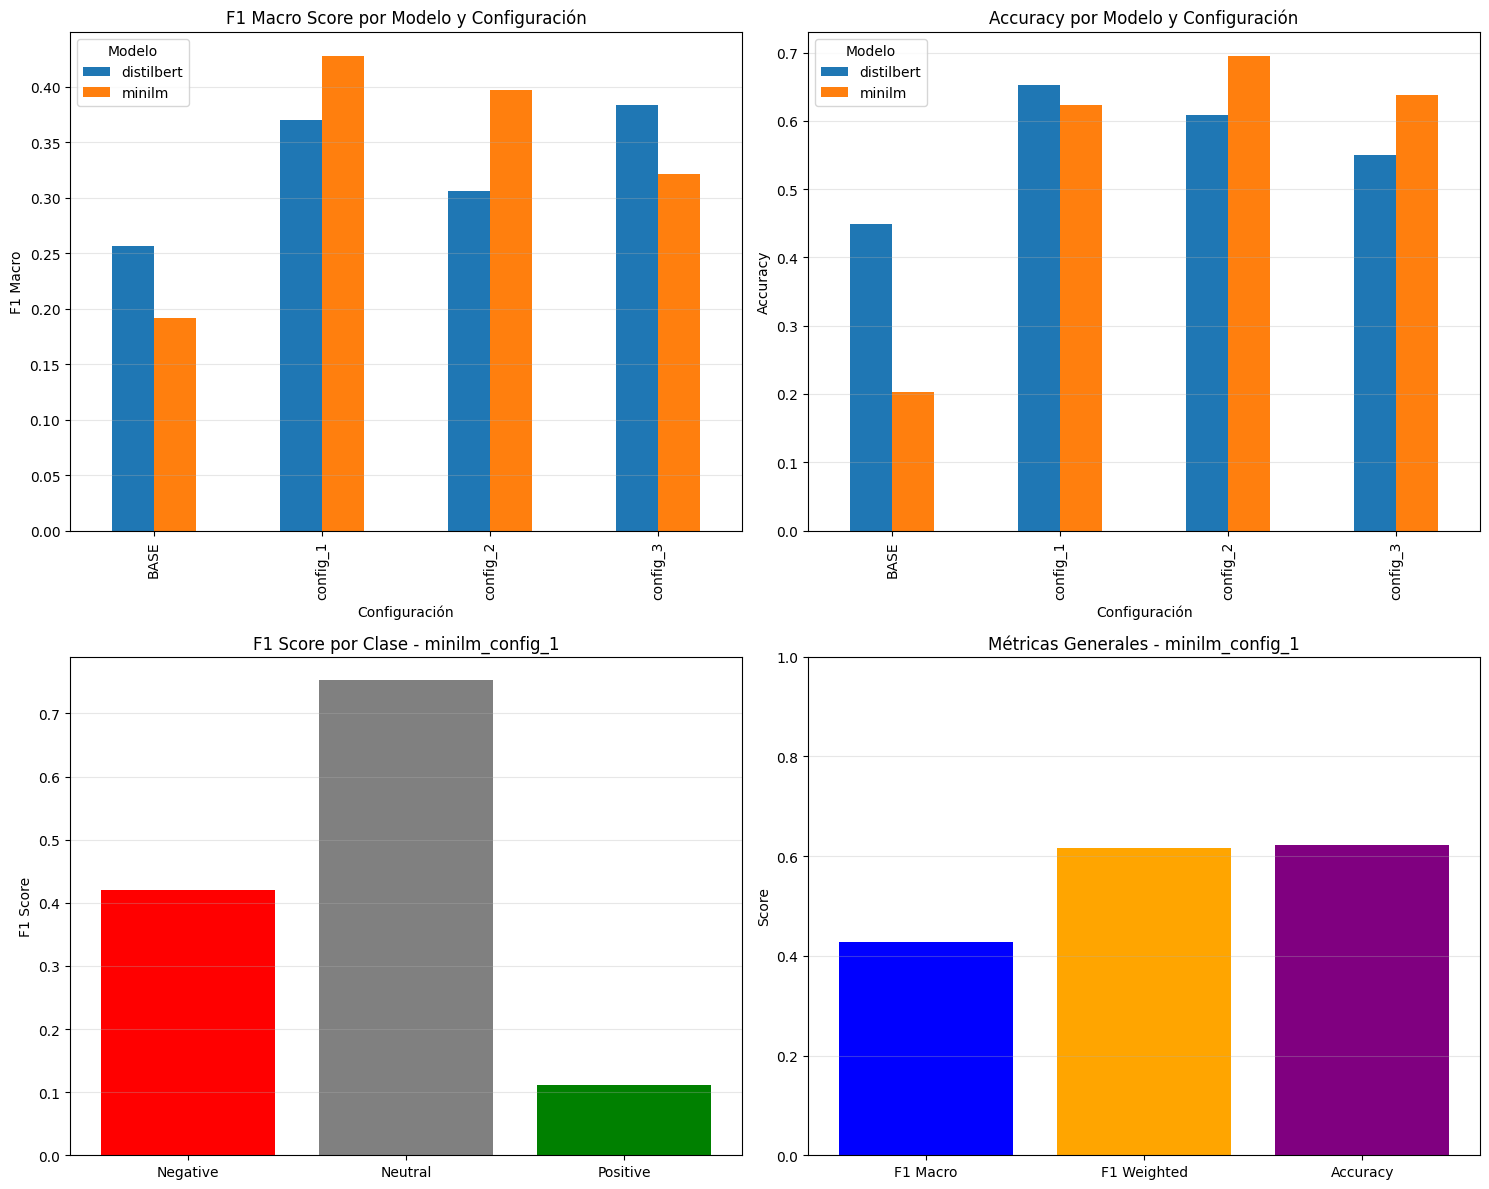


✅ Gráficos guardados en: 2_Modelos/sentiment/model_comparison_plots.png


In [20]:
# Gráfico de comparación de F1 Macro
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# F1 Macro por modelo y configuración
ax1 = axes[0, 0]
comparison_df_pivot = comparison_df.pivot(index="config", columns="model", values="test_f1_macro")
comparison_df_pivot.plot(kind="bar", ax=ax1)
ax1.set_title("F1 Macro Score por Modelo y Configuración")
ax1.set_ylabel("F1 Macro")
ax1.set_xlabel("Configuración")
ax1.legend(title="Modelo")
ax1.grid(axis='y', alpha=0.3)

# Accuracy por modelo y configuración
ax2 = axes[0, 1]
comparison_df_pivot_acc = comparison_df.pivot(index="config", columns="model", values="test_accuracy")
comparison_df_pivot_acc.plot(kind="bar", ax=ax2)
ax2.set_title("Accuracy por Modelo y Configuración")
ax2.set_ylabel("Accuracy")
ax2.set_xlabel("Configuración")
ax2.legend(title="Modelo")
ax2.grid(axis='y', alpha=0.3)

# F1 por clase del mejor modelo
ax3 = axes[1, 0]
f1_by_class = {
    "Negative": best_model_data["metrics"]["test_f1_negative"],
    "Neutral": best_model_data["metrics"]["test_f1_neutral"],
    "Positive": best_model_data["metrics"]["test_f1_positive"],
}
ax3.bar(f1_by_class.keys(), f1_by_class.values(), color=['red', 'gray', 'green'])
ax3.set_title(f"F1 Score por Clase - {best_experiment}")
ax3.set_ylabel("F1 Score")
ax3.grid(axis='y', alpha=0.3)

# Comparación general de métricas del mejor modelo
ax4 = axes[1, 1]
metrics_comparison = {
    "F1 Macro": best_model_data["metrics"]["test_f1_macro"],
    "F1 Weighted": best_model_data["metrics"]["test_f1_weighted"],
    "Accuracy": best_model_data["metrics"]["test_accuracy"],
}
ax4.bar(metrics_comparison.keys(), metrics_comparison.values(), color=['blue', 'orange', 'purple'])
ax4.set_title(f"Métricas Generales - {best_experiment}")
ax4.set_ylabel("Score")
ax4.set_ylim([0, 1])
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison_plots.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráficos guardados en: {OUTPUT_DIR / 'model_comparison_plots.png'}")


## 13. Matriz de confusión del mejor modelo

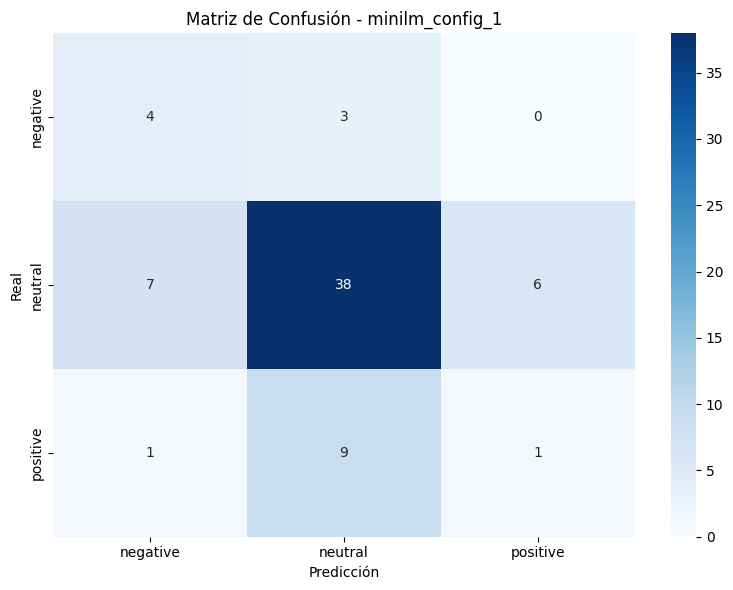

✅ Matriz de confusión guardada en 2_Modelos/sentiment/best_model_confusion_matrix.png


In [21]:
def plot_confusion_matrix(true_labels, pred_labels, exp_name, out_path):
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=list(LABEL2ID.keys()), 
                yticklabels=list(LABEL2ID.keys()),
                cmap='Blues')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title(f'Matriz de Confusión - {exp_name}')
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()
    print(f'✅ Matriz de confusión guardada en {out_path}')

# Generar matriz de confusión del mejor modelo
plot_confusion_matrix(
    best_model_data["labels"],
    best_model_data["predictions"],
    best_experiment,
    OUTPUT_DIR / "best_model_confusion_matrix.png"
)


## 14. Classification report del mejor modelo

In [22]:
print("\n" + "="*80)
print(f"CLASSIFICATION REPORT - {best_experiment}")
print("="*80 + "\n")

print(classification_report(
    best_model_data["labels"], 
    best_model_data["predictions"], 
    target_names=list(LABEL2ID.keys())
))



CLASSIFICATION REPORT - minilm_config_1

              precision    recall  f1-score   support

    negative       0.33      0.57      0.42         7
     neutral       0.76      0.75      0.75        51
    positive       0.14      0.09      0.11        11

    accuracy                           0.62        69
   macro avg       0.41      0.47      0.43        69
weighted avg       0.62      0.62      0.62        69



## 15. Exportar predicciones del mejor modelo

In [23]:
# Preparar dataframe con resultados del mejor modelo
pred_probs = best_model_data["probabilities"]
pred_labels = best_model_data["predictions"]
true_labels = best_model_data["labels"]

results_df = test_df.reset_index(drop=True).copy()
results_df["true_label"] = [ID2LABEL[i] for i in true_labels]
results_df["pred_label"] = [ID2LABEL[i] for i in pred_labels]

# Agregar las probabilidades de cada clase
for i, label_name in ID2LABEL.items():
    results_df[f"prob_{label_name}"] = pred_probs[:, i]

# Agregar información del modelo usado
results_df["model_used"] = best_experiment
results_df["model_f1_macro"] = best_model_data["metrics"]["test_f1_macro"]
results_df["model_accuracy"] = best_model_data["metrics"]["test_accuracy"]

# Guardar a CSV y Parquet
results_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
results_df.to_parquet(OUTPUT_DIR / "test_predictions.parquet", index=False)

print(f"\n✅ Predicciones exportadas:")
print(f"   - CSV: {OUTPUT_DIR / 'test_predictions.csv'}")
print(f"   - Parquet: {OUTPUT_DIR / 'test_predictions.parquet'}")
print(f"\n📊 Shape: {results_df.shape}")
print(f"📋 Columnas: {list(results_df.columns)}")



✅ Predicciones exportadas:
   - CSV: 2_Modelos/sentiment/test_predictions.csv
   - Parquet: 2_Modelos/sentiment/test_predictions.parquet

📊 Shape: (69, 18)
📋 Columnas: ['title', 'description', 'content', 'text', 'source', 'author', 'publishedAt', 'url', 'sentiment', 'label', 'true_label', 'pred_label', 'prob_negative', 'prob_neutral', 'prob_positive', 'model_used', 'model_f1_macro', 'model_accuracy']


## 16. Resumen Final

In [24]:
print("\n" + "="*80)
print("RESUMEN FINAL DEL EXPERIMENTO")
print("="*80 + "\n")

print(f"Total de experimentos: {len(all_results)}")
print(f"Modelos evaluados: {len(MODELS_TO_COMPARE)}")
print(f"Configuraciones por modelo: {len(CONFIGS)}")
print(f"\n🏆 Mejor modelo: {best_experiment}")
print(f"   - F1 Macro: {best_model_data['metrics']['test_f1_macro']:.4f}")
print(f"   - Accuracy: {best_model_data['metrics']['test_accuracy']:.4f}")
print(f"   - F1 Negative: {best_model_data['metrics']['test_f1_negative']:.4f}")
print(f"   - F1 Neutral: {best_model_data['metrics']['test_f1_neutral']:.4f}")
print(f"   - F1 Positive: {best_model_data['metrics']['test_f1_positive']:.4f}")

print(f"\n📁 Archivos generados:")
print(f"   - Comparación de modelos: {OUTPUT_DIR / 'model_comparison.csv'}")
print(f"   - Gráficos comparativos: {OUTPUT_DIR / 'model_comparison_plots.png'}")
print(f"   - Matriz de confusión: {OUTPUT_DIR / 'best_model_confusion_matrix.png'}")
print(f"   - Predicciones finales: {OUTPUT_DIR / 'test_predictions.csv'}")
print(f"   - Modelos entrenados: {OUTPUT_DIR / '<modelo>_<config>/final_model/'}")

print("\n" + "="*80)
print("✅ EXPERIMENTO COMPLETADO EXITOSAMENTE")
print("="*80)



RESUMEN FINAL DEL EXPERIMENTO

Total de experimentos: 8
Modelos evaluados: 2
Configuraciones por modelo: 3

🏆 Mejor modelo: minilm_config_1
   - F1 Macro: 0.4282
   - Accuracy: 0.6232
   - F1 Negative: 0.4211
   - F1 Neutral: 0.7525
   - F1 Positive: 0.1111

📁 Archivos generados:
   - Comparación de modelos: 2_Modelos/sentiment/model_comparison.csv
   - Gráficos comparativos: 2_Modelos/sentiment/model_comparison_plots.png
   - Matriz de confusión: 2_Modelos/sentiment/best_model_confusion_matrix.png
   - Predicciones finales: 2_Modelos/sentiment/test_predictions.csv
   - Modelos entrenados: 2_Modelos/sentiment/<modelo>_<config>/final_model

✅ EXPERIMENTO COMPLETADO EXITOSAMENTE
